# Actividad 14 randomo forest

En este codigo buscaremos predecir si una persona tendra ingresos altos o bajos.
dadas estas condiciones nuestra variable objetivo es *Ingres_economico*, es una varible naturaleza de clasificaion. Usaremos varibles de tipo. *Horas_de_trabajo*, *años_de_estudio*, *Edad*, *tipo_de_trabajo*.

*Edad*: cantidad de años

*años_de_estudio*: cantidad de años de estudio

*genero*: cual genero entre hombre y mujer (0 y1)

*tipo de trabajo*; es entre si es gubernamental o no (0 y 1)

*horas_de_trabajo*: es la cantidad de horas de trabajo

Estaremos creando tres arboles de desición. Formando un bosque aleatorio.



# Actividad 14: Bosques Aleatorios (Random Forest)
**Materia:** Presentación del Análisis Prescriptivo de los Datos  
**Carrera:** Ciencia de Datos e Inteligencia Artificial (CDIA)  
**Plantel:** CONALEP Tepic 169  

---

## Parte 1: Explicación Amplia del Tema (Bosques Aleatorios)

Los **Bosques Aleatorios (Random Forest)** representan una de las técnicas de aprendizaje de máquina (*Machine Learning*) supervisado más robustas y utilizadas en la actualidad, siendo aplicable tanto para resolver problemas de **clasificación** (predecir categorías) como de **regresión** (predecir valores numéricos continuos).

### El Paradigma de la Sabiduría de las Masas
Esta técnica se basa en el principio estadístico de la **"sabiduría de las masas"** (*Wisdom of the Crowds*). En lugar de confiar el análisis a un único modelo predictivo, un bosque aleatorio construye un conjunto (*Ensemble*) de múltiples estimadores base: los **árboles de decisión**.
*   **Mecanismo de Clasificación:** Cada árbol del bosque analiza la instancia y emite un voto por una clase. La predicción final del bosque se determina mediante el **voto de la mayoría** o ponderado por probabilidades.
*   **Mecanismo de Regresión:** Si el objetivo es predecir un valor numérico, el bosque promedia aritméticamente las salidas individuales de todos sus árboles componentes.

### El Problema de la Varianza y el Sobreajuste (Overfitting)
Los árboles de decisión individuales son intuitivos y rápidos, pero adolecen de un defecto crítico: sufren de **alta variabilidad** y tienden a **sobreajustarse** a los datos de entrenamiento. Esto significa que memorizan los patrones específicos (e incluso el ruido) de su set de datos, perdiendo la capacidad de generalizar correctamente ante datos nuevos del mundo real.
Al agruparlos en un bosque, el error o sesgo particular de un árbol se compensa y se diluye con las predicciones correctas de los demás, reduciendo drásticamente la varianza general y convirtiendo el modelo en una herramienta predictiva de alta estabilidad.

### Estrategias de Aleatorización
Para que el paradigma funcione, es indispensable que los árboles no sean idénticos entre sí. El algoritmo Random Forest introduce aleatoriedad artificial en dos niveles distintos:

1.  **Muestreo con Reemplazo (Bootstrapping / Bagging):** Cada árbol individual se entrena con un subconjunto aleatorio extraído del dataset original (comúnmente una proporción de dos tercios o 66.6%). Al ser un muestreo "con reemplazo", algunas filas se duplicarán dentro del mismo árbol, mientras que otras quedarán completamente excluidas de su entrenamiento.
2.  **Selección Aleatoria de Características (Subspace Sampling):** En un árbol tradicional, cada nodo busca la mejor variable absoluta de todo el dataset para dividir las ramas utilizando métricas como la Impureza de Gini o la Entropía. En Random Forest, cada vez que un árbol genera un nodo de decisión, se le restringe a evaluar únicamente un subconjunto de variables elegidas al azar. Experimentalmente, la regla de oro para determinar este tamaño es la raíz cuadrada del total de características disponibles ($max\_features = \sqrt{\text{características}}$). Esto rompe el determinismo y evita que una sola variable dominante vuelva homogéneo a todo el bosque.

### Evaluación Out-of-Bag (OOB)
Dado que cada árbol se entrena usando solo una fracción de los datos, queda un remanente aproximado de un tercio (1/3) de los datos que ese árbol jamás observó. A estas instancias se les llama **Out-of-Bag (Fuera de la bolsa)**.
El **OOB Score** evalúa el desempeño de cada árbol empleando exclusivamente sus respectivas filas fuera de la bolsa. Funciona como un sistema de validación cruzada automática integrado, proporcionando una estimación honesta y realista de la capacidad de generalización del modelo ante datos desconocidos, contrastando con la métrica de exactitud en entrenamiento que suele estar inflada por la memoria del algoritmo.


---

## Parte 2: Elaboración del Código de Ejemplo

A continuación, se desarrolla el flujo completo del algoritmo enfocado en un caso práctico prescriptivo: **determinar si una persona tendrá un ingreso económico alto (1) o bajo (0)**.

### Variables del Dataset (`ingresos.csv`):
*   **Variables Predictoras (Features):** Edad, años de estudio, género (0 y 1), tipo de trabajo (0 para gubernamental, 1 para privado) y horas de trabajo semanales.
*   **Variable Objetivo (Target):** Ingreso (`ingreso`).


In [9]:
#importacion de la libreria base y carga del conjunto de datos
import pandas as pd
#lectura del archivo csv generado para el ejecicio
Personas = pd.read_csv("/content/ingresos.csv")
Personas

,edad,estudio,genero,tipo_trabajo,horas,ingreso
0,27,9,0,0,40,0
1,30,9,0,0,40,0
2,34,8,0,0,40,0
3,26,13,0,0,50,0
4,23,4,1,0,25,0
...,...,...,...,...,...,...
95,32,13,1,0,55,1
96,20,10,0,0,25,0
97,46,3,0,0,40,0
98,37,9,1,0,45,0


#Muestreo con remplazo

Es necesario tomar una muestra para cada arbol, po lo que se dividiran los datos de la base de datos para cada arbol de desición.

### Paso 2.1: Demostración del Muestreo con Reemplazo (Bootstrapping)
Para observar el comportamiento de la aleatoriedad en las instancias (filas), ejecutamos tres simulaciones utilizando el método `.sample()`. Cada árbol del bosque recibirá un conjunto de datos único conformado por el 66.6% (`frac=2/3`) de la información original, permitiendo la repetición de registros mediante `replace=True`.


In [10]:
#Simulación del muestreo de datos independientes para 3 arboles distintos
print(Personas.sample(frac=2/3, replace=True))
print(Personas.sample(frac=2/3, replace=True))
print(Personas.sample(frac=2/3, replace=True))

    edad  estudio  genero  tipo_trabajo  horas  ingreso
68    58       13       1             0     40        0
45    54       13       1             1     40        1
90    59        9       0             0     35        0
13    58        9       0             0     40        0
28    30        9       1             1     60        0
..   ...      ...     ...           ...    ...      ...
44    36       14       1             0     60        1
93    47       15       1             0     40        1
39    37        9       1             1     40        0
92    32        9       1             0     48        0
69    40        9       0             0     40        0

[67 rows x 6 columns]
    edad  estudio  genero  tipo_trabajo  horas  ingreso
98    37        9       1             0     45        0
95    32       13       1             0     55        1
92    32        9       1             0     48        0
56    34       13       0             0     39        0
93    47       15       1

#Aleatoriedad:

**Seleccion de Caracteristicas para Diviciones**

las caracteristicas se seleccionan al azar, de esa manera los arboles seran aleatoriamente distintos, esto es interesante porque de esta manera el bosque aleatorio tiene mayor poder predictivo, tiene menos varianza, eso es bueno para las predicciones y clasificacione.


Dicen que las caracteristicas que tienes que extraer aleatoriamente van en funcion del total de numero de caracteristicas que tienes y a eso le sacas la raiz cuadrada: *>>>>>max_features = √num_caracteristicas<<<<<*

### Paso 2.2: Demostración de Selección de Características
Aislando las variables predictoras (todas las columnas excepto la última correspondiente al objetivo), simulamos la técnica donde el nodo de un árbol selecciona de forma aleatoria únicamente 3 características para evaluar sus divisiones. Esto reduce la varianza y el sesgo del bosque.


In [11]:
from random import sample

print(Personas.columns[:-1], "\n")
print(sample(list(Personas.columns[:-1]), 3)) # Identificación de variables predictoras en el DataFrame

Index(['edad', 'estudio', 'genero', 'tipo_trabajo', 'horas'], dtype='object') 

['edad', 'genero', 'tipo_trabajo']


#Creacion del Bosque Aleatorio (Random Forest).



### Paso 2.3: Construcción, Entrenamiento y Evaluación del Random Forest
Utilizando la librería `scikit-learn`, instanciamos el objeto `RandomForestClassifier`. Configuramos sus hiperparámetros de acuerdo a las directrices pedagógicas: un ensamble de 100 árboles, criterio de impureza de Gini, selección de variables mediante raíz cuadrada (`sqrt`), y habilitamos el cálculo del `oob_score` para obtener la validación real del modelo.


In [15]:
from sklearn.ensemble import RandomForestClassifier

# 1. Configuración del clasificador con hiperparámetros analíticos
bosque = RandomForestClassifier(n_estimators=100, #va a crear cien arboles y tomara en cuenta cada uno para la toma de la decisión
                                criterion="gini", # Métrica para evaluar la calidad de los cortes
                                max_features="sqrt", # Cantidad máxima de características aleatorias por nodo
                                bootstrap=True,  # Muestreo con reemplazo activo
                                max_samples=2/3, #cada uno de los arboles estan siendo creados usando 2/3 de los datos. Esto es lo que esta dentro de la bolsa en esta alegria de la bolsa
                                oob_score=True) #este parametro es una metrica especial para los bosques aleatorios. Este parametro podria traducirse como 'fuera de la bolsa' 'out of bag'

#hasta este punto ya esta configurada la creacion del bosque aleatorio pero no le emos pasado datos


bosque.fit(Personas[Personas.columns[:-1]].values, Personas["ingreso"].values)


print(bosque.predict([[50, 16, 1, 1, 40]]))
print(bosque.score(Personas[Personas.columns[:-1]].values, Personas["ingreso"].values))
print(bosque.oob_score_)

[1]
0.97
0.79


#Visualizacion del bosque aleatorio

### Paso 2.4: Visualización Estructurada de los Árboles del Bosque
Finalmente, accedemos al atributo `.estimators_` del objeto entrenado para extraer y graficar los árboles individuales que integran el bosque. Esto permite comprobar visualmente cómo las técnicas de aleatorización aplicadas anteriormente generan estructuras morfológicas completamente diferentes y variadas entre sí.


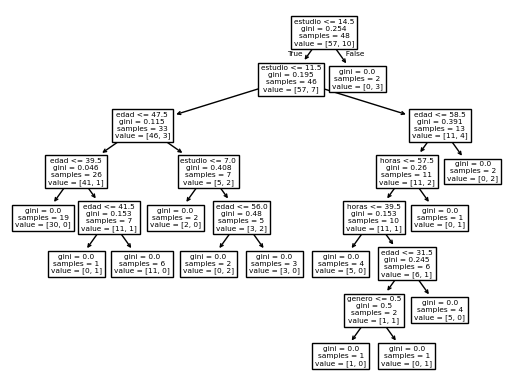

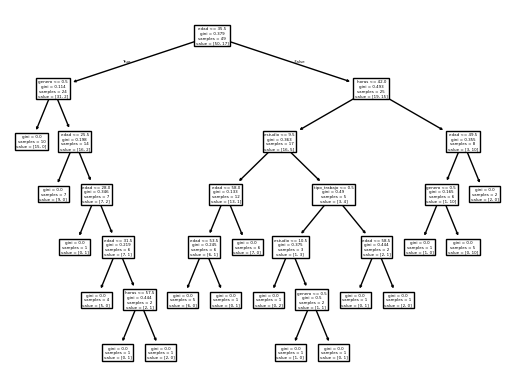

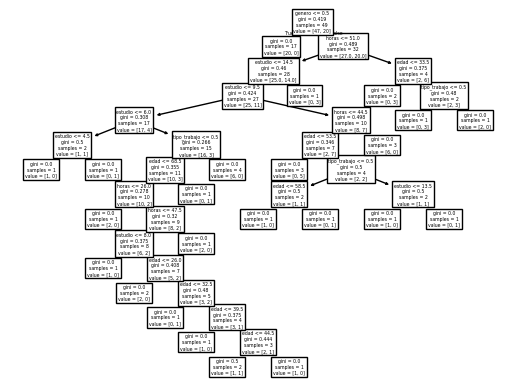

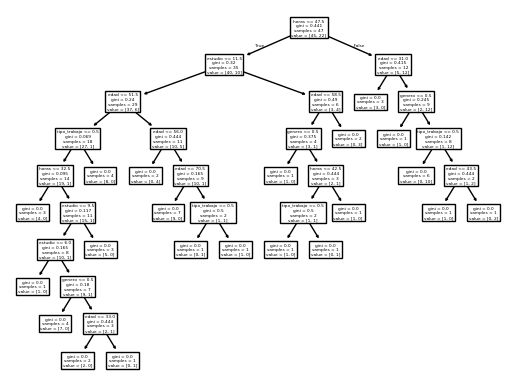

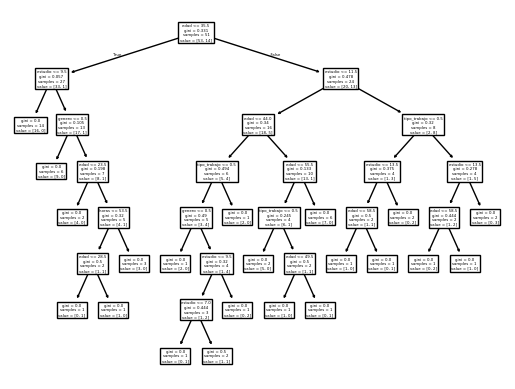

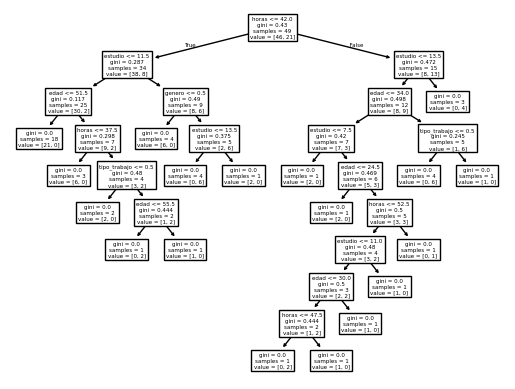

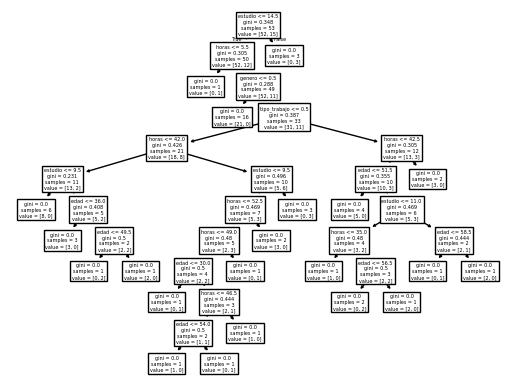

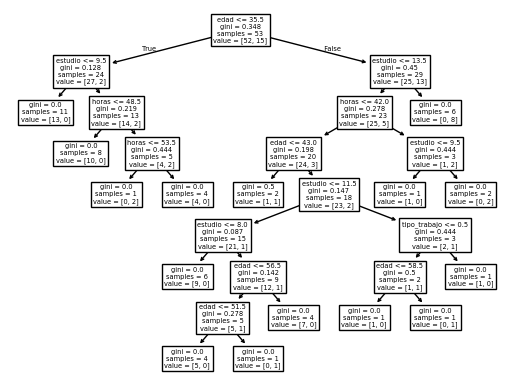

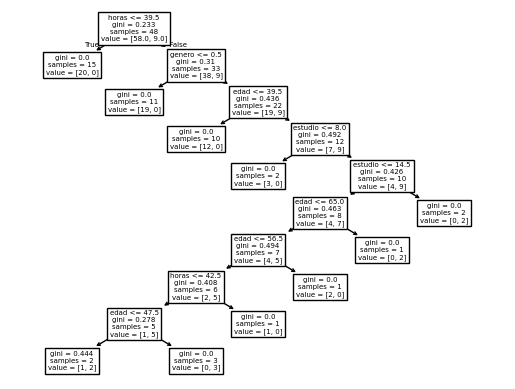

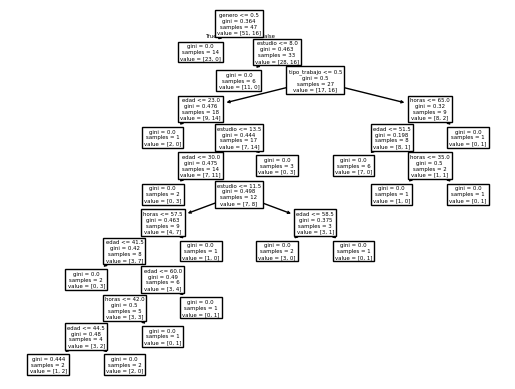

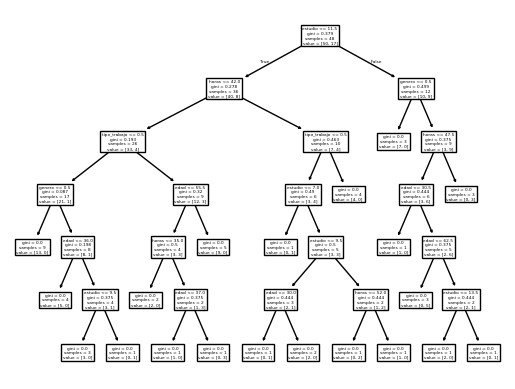

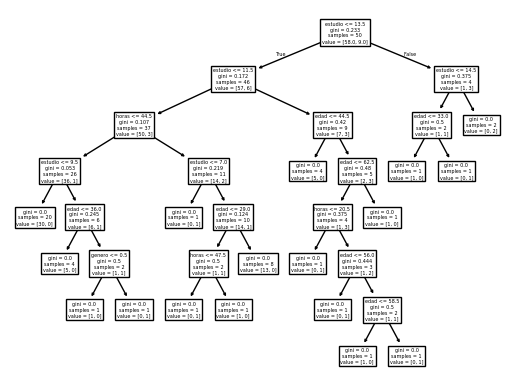

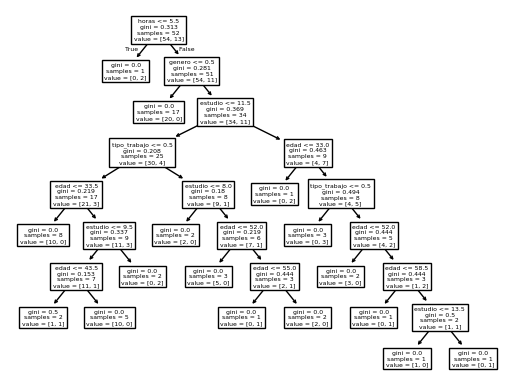

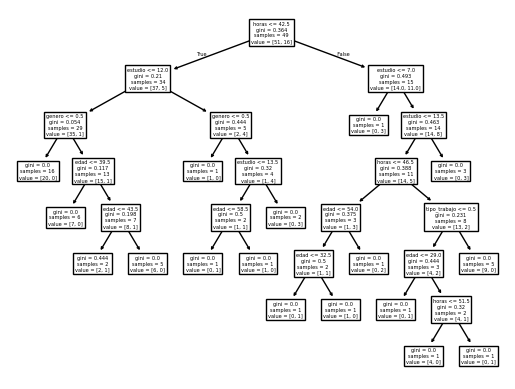

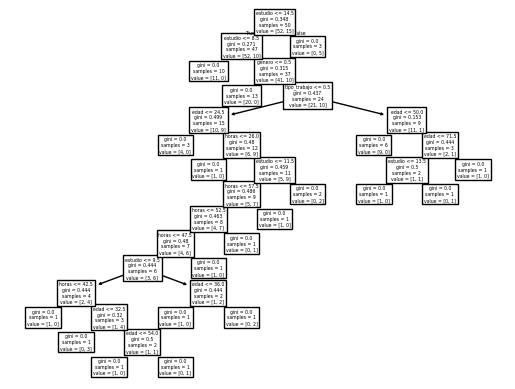

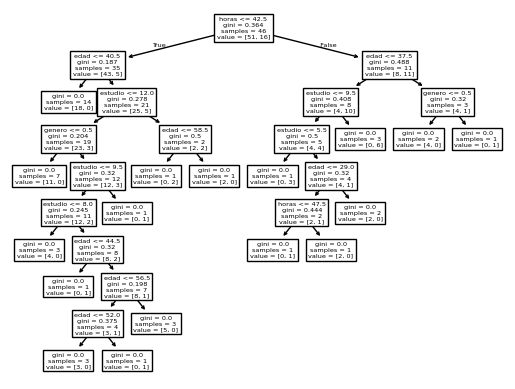

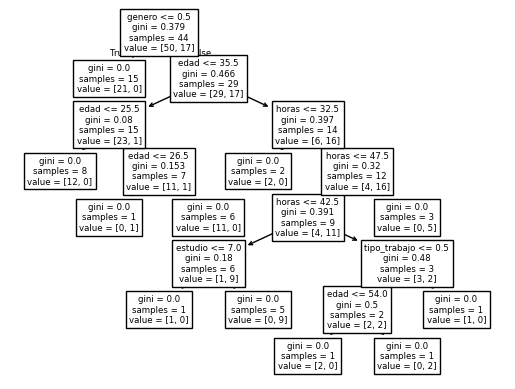

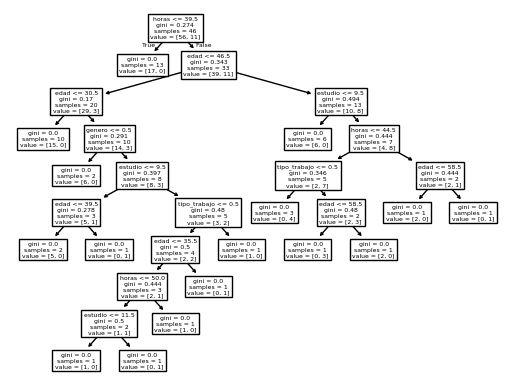

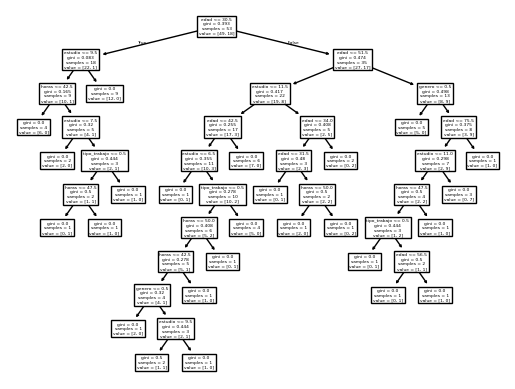

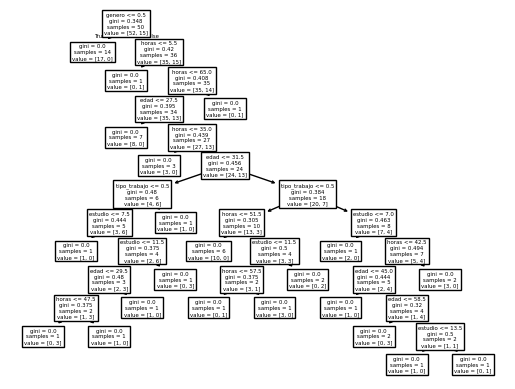

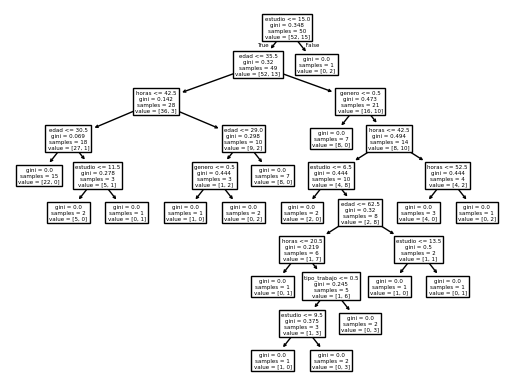

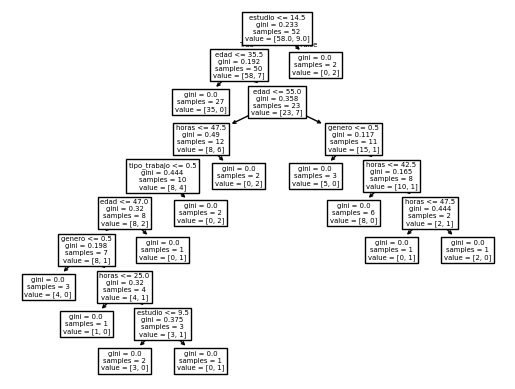

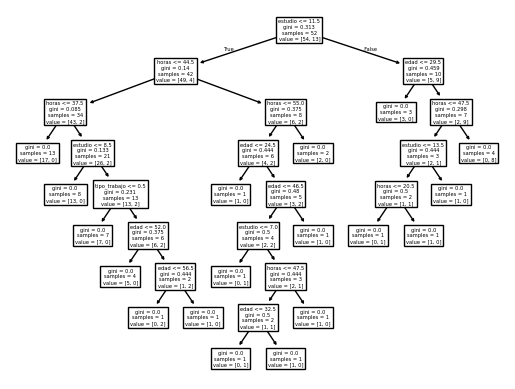

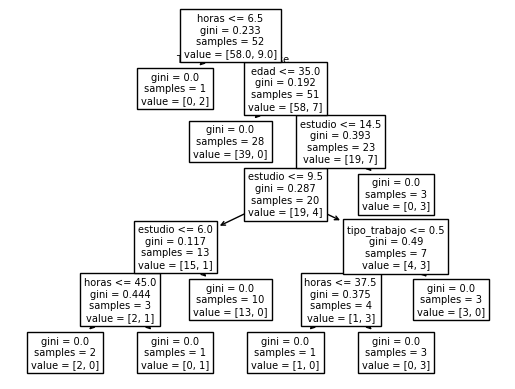

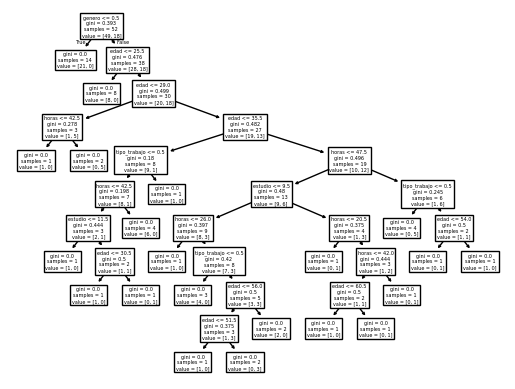

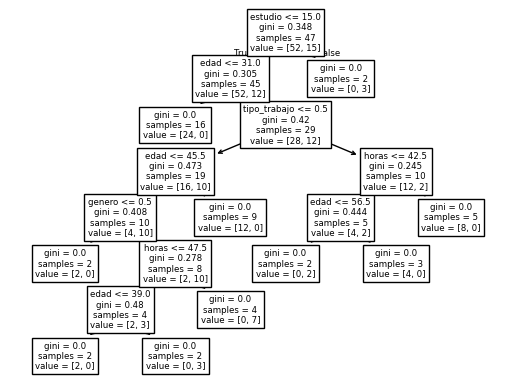

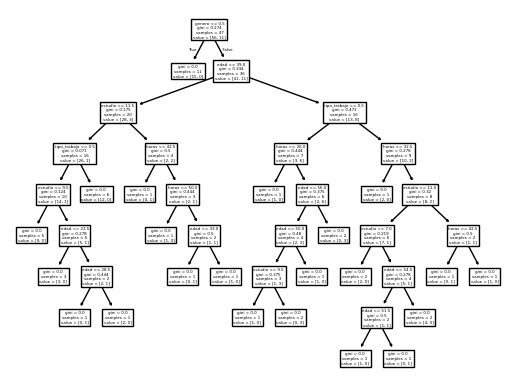

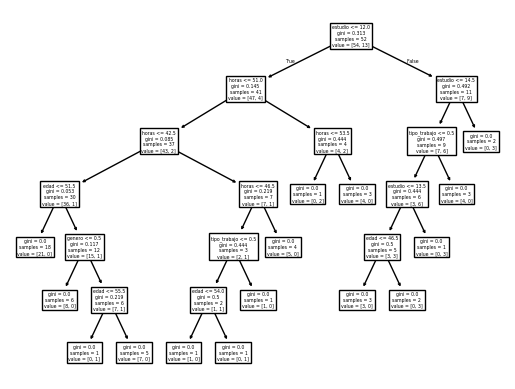

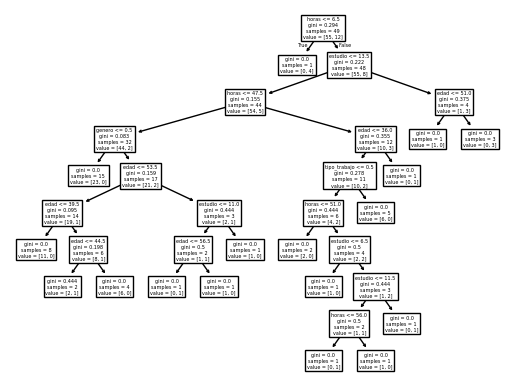

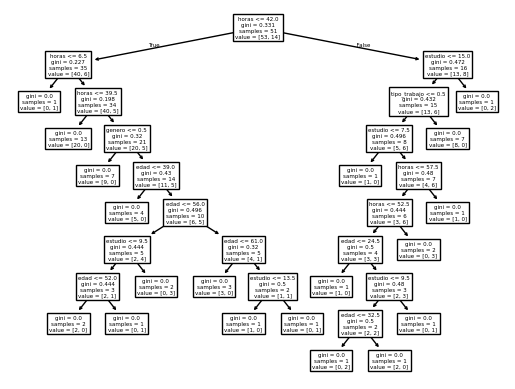

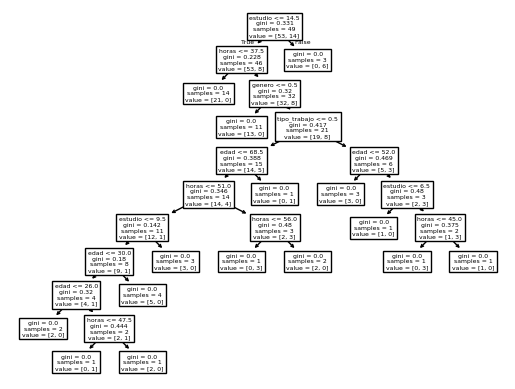

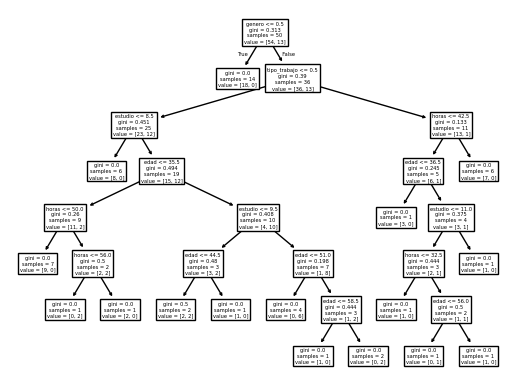

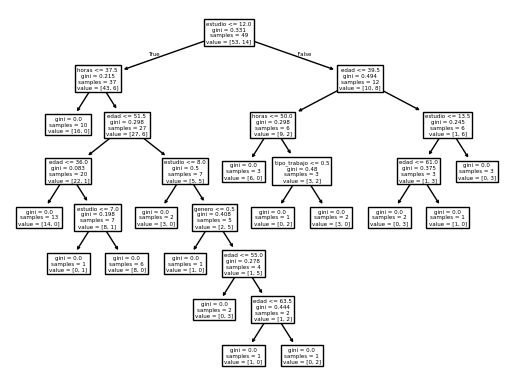

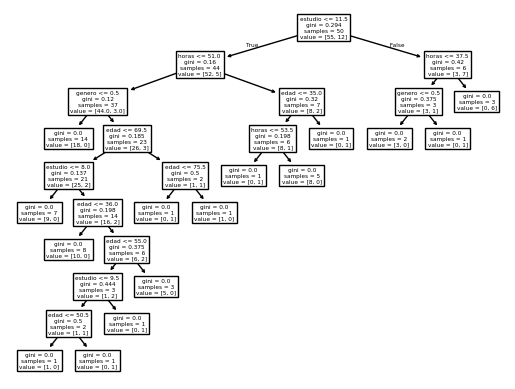

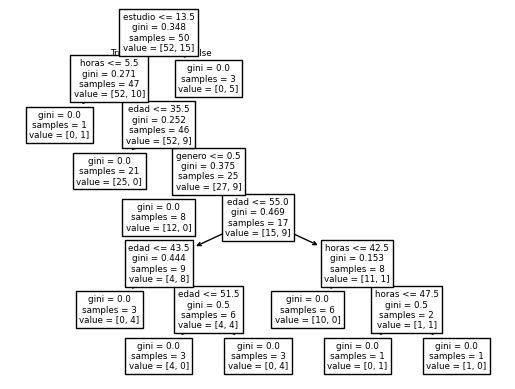

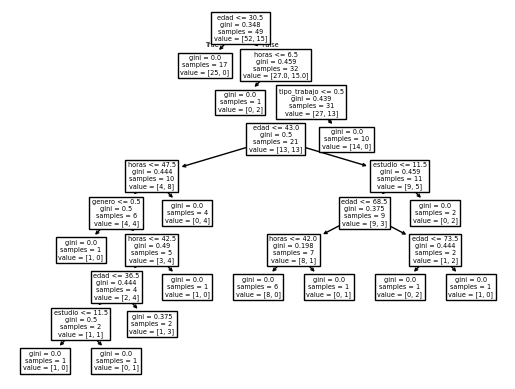

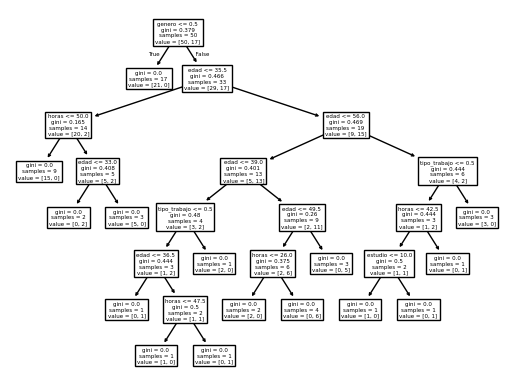

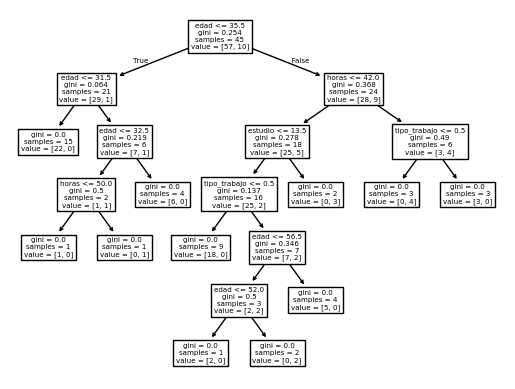

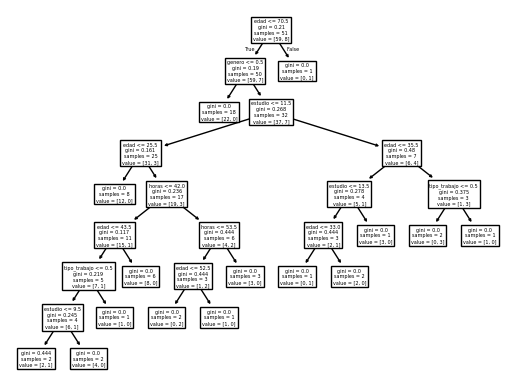

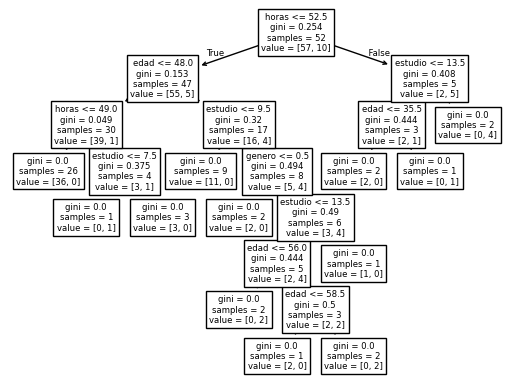

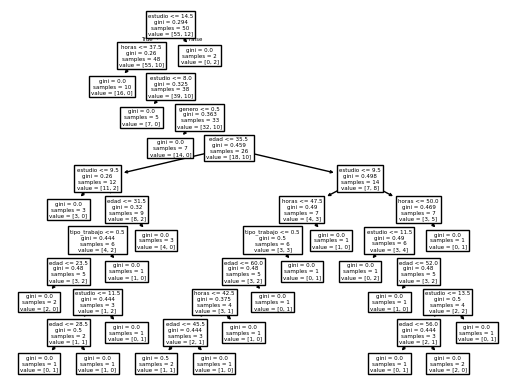

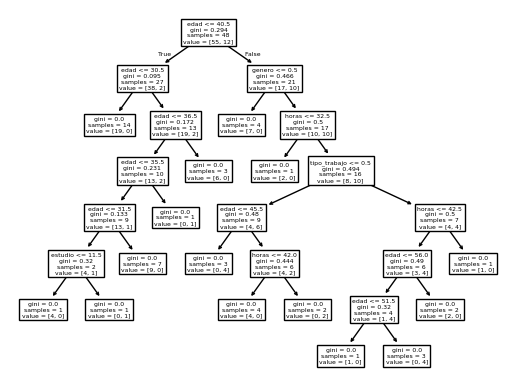

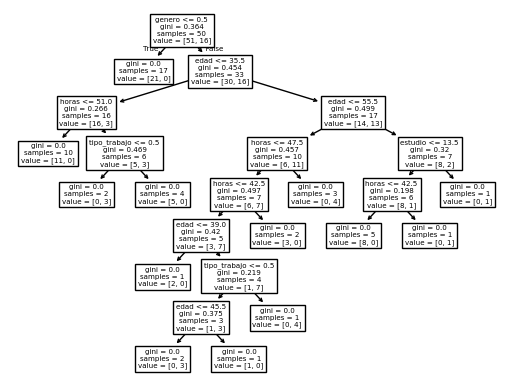

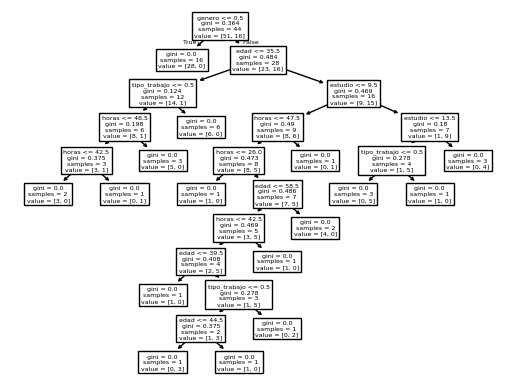

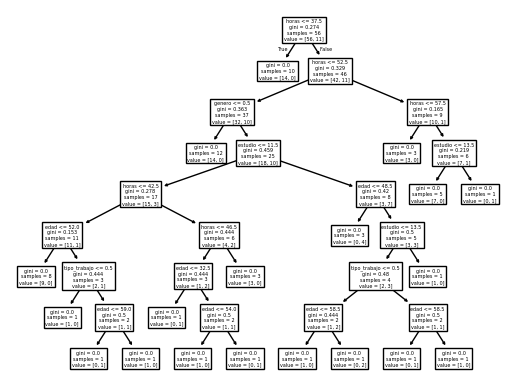

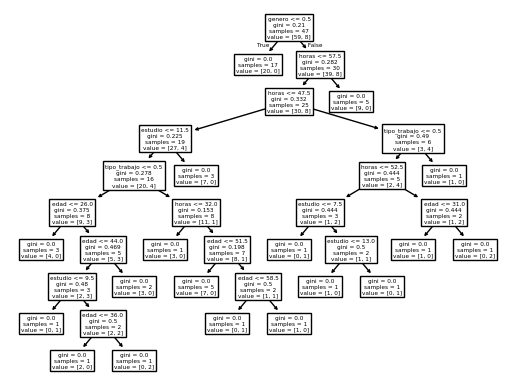

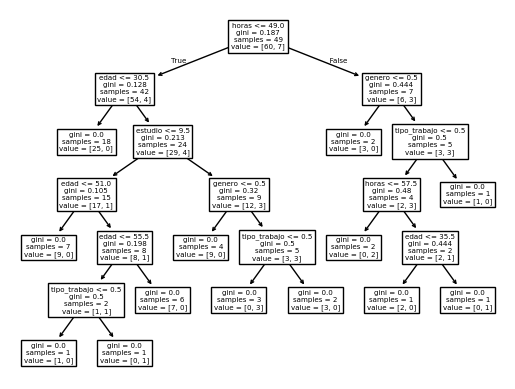

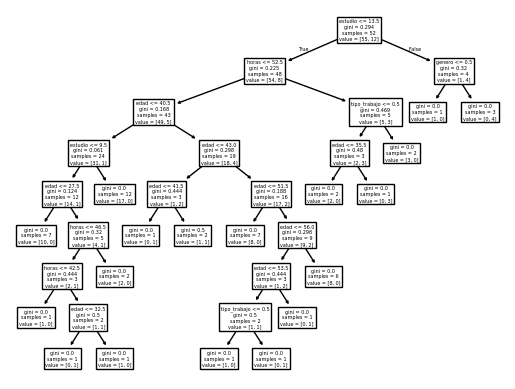

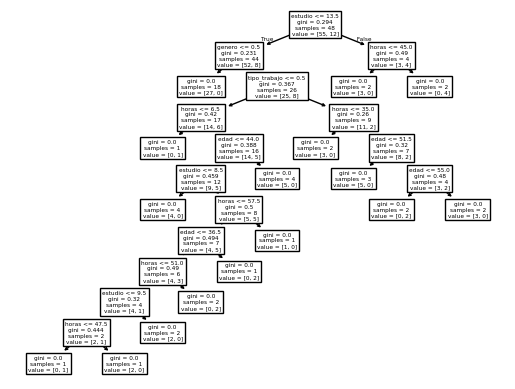

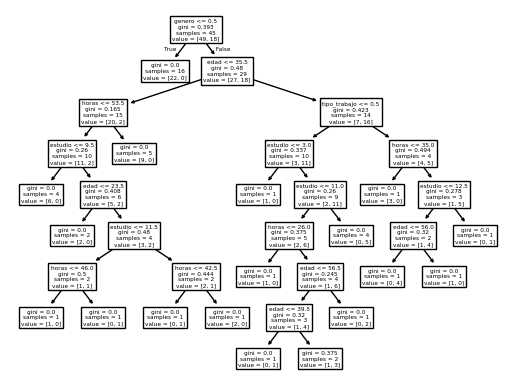

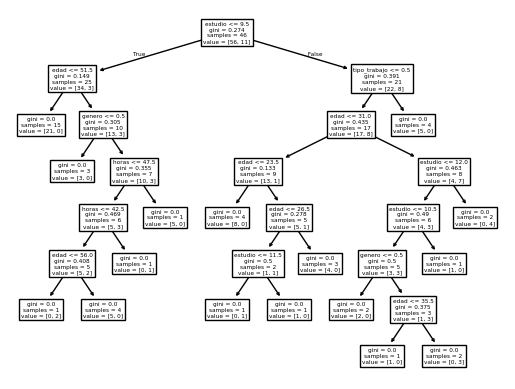

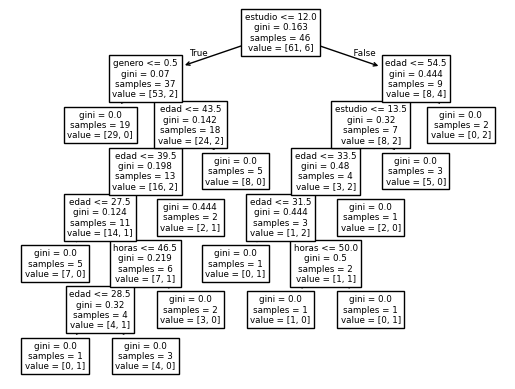

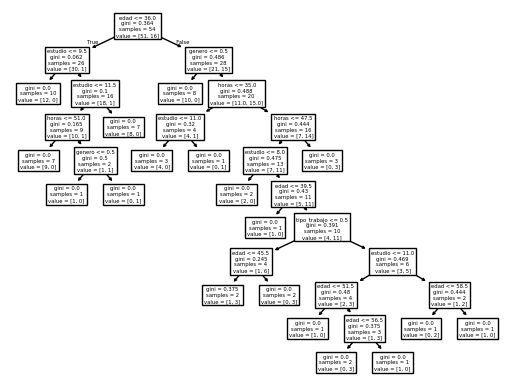

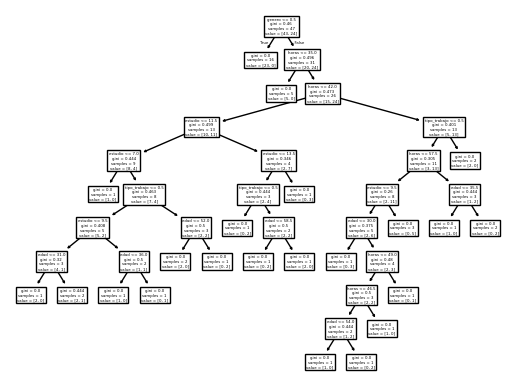

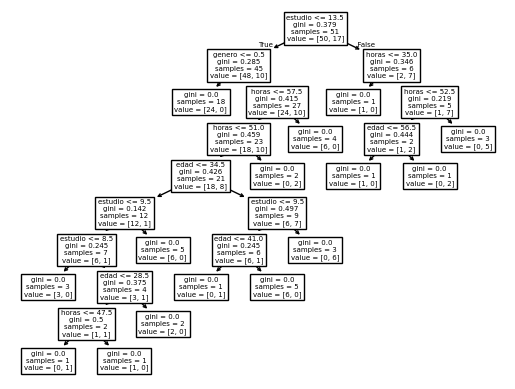

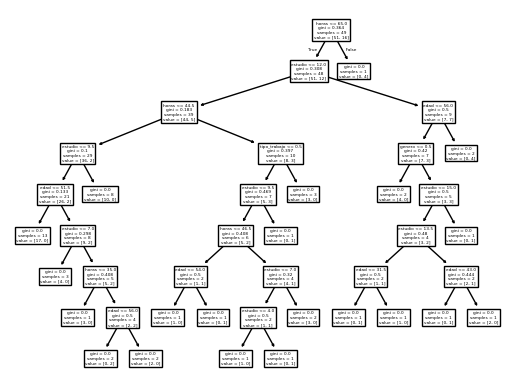

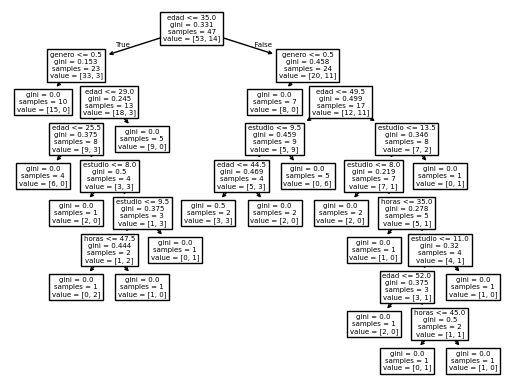

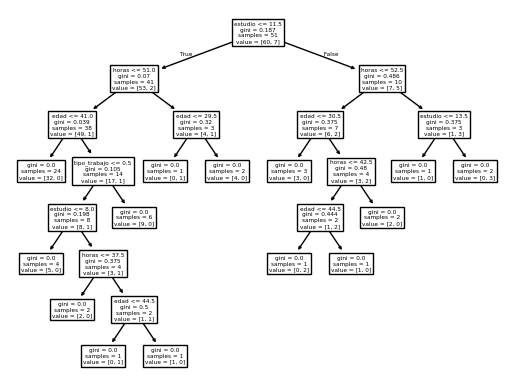

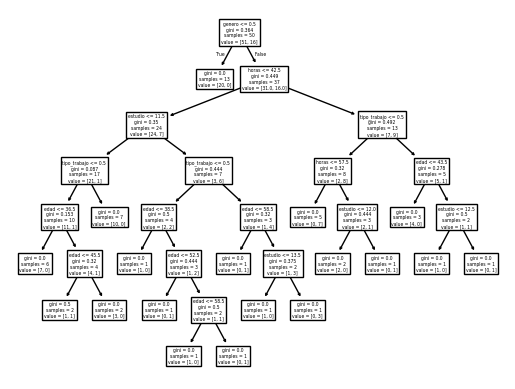

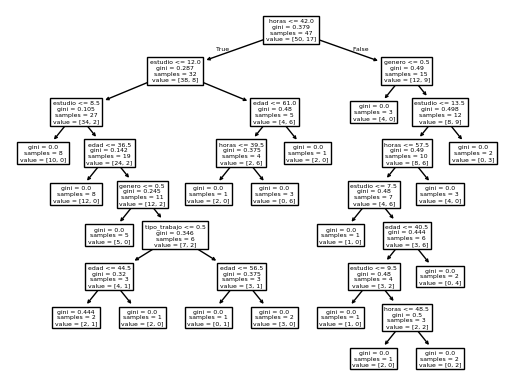

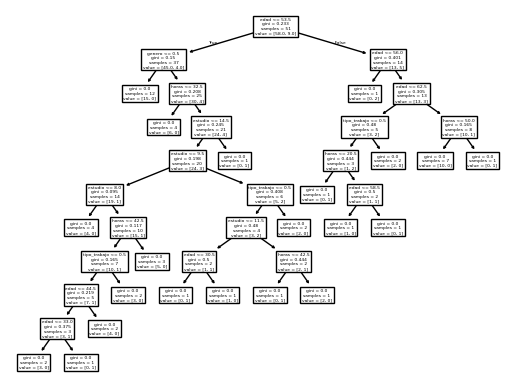

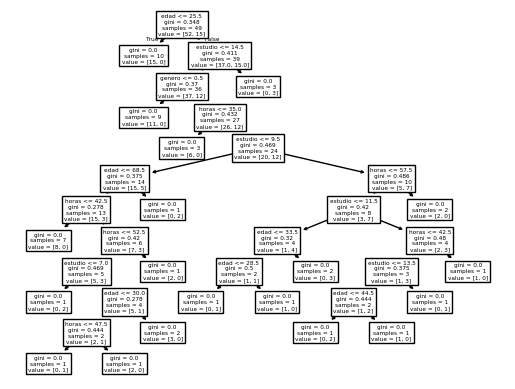

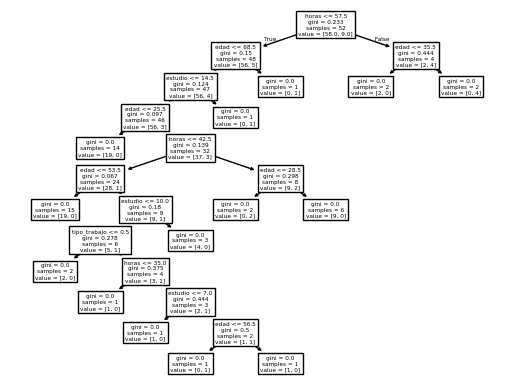

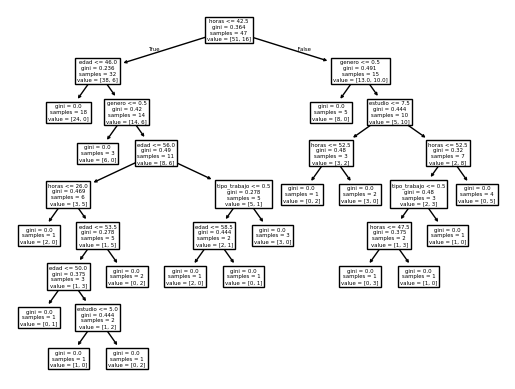

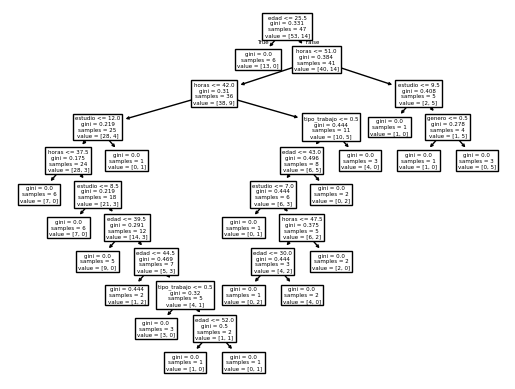

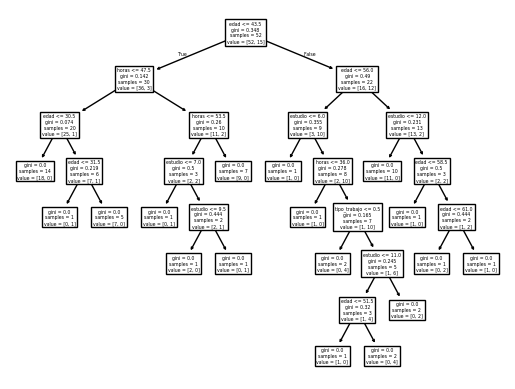

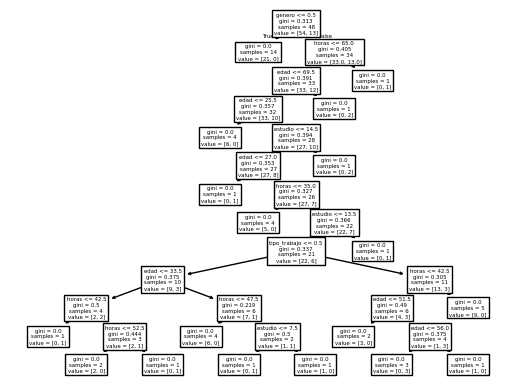

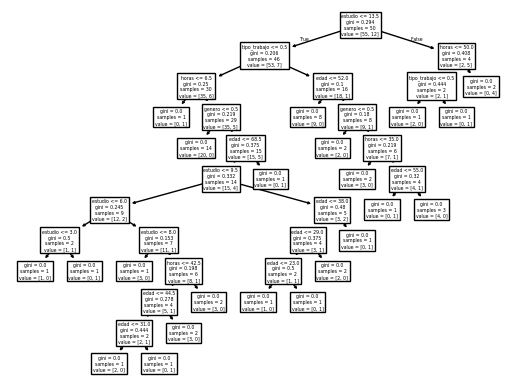

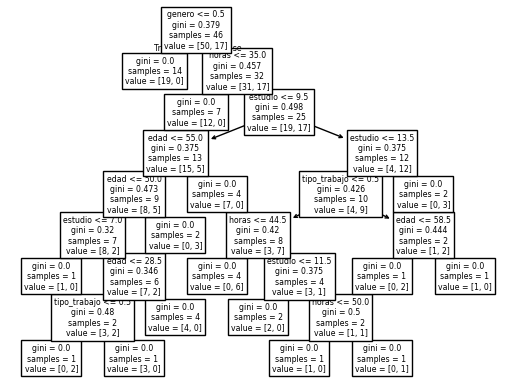

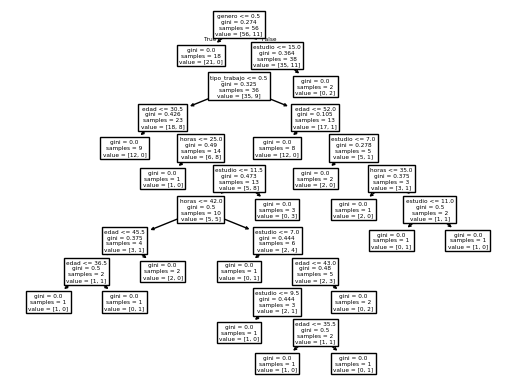

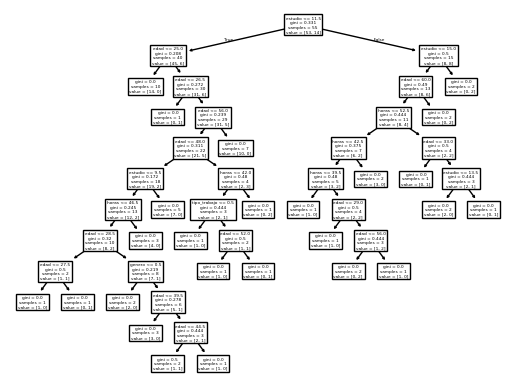

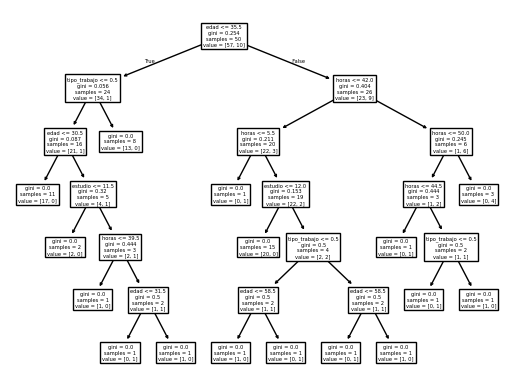

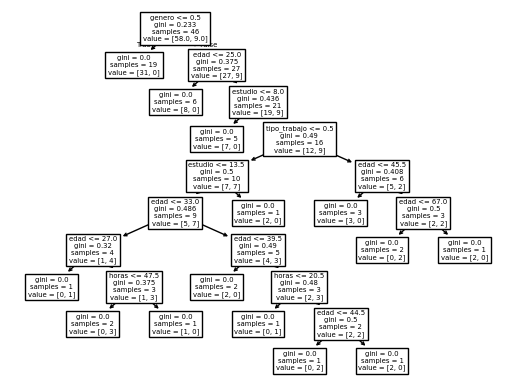

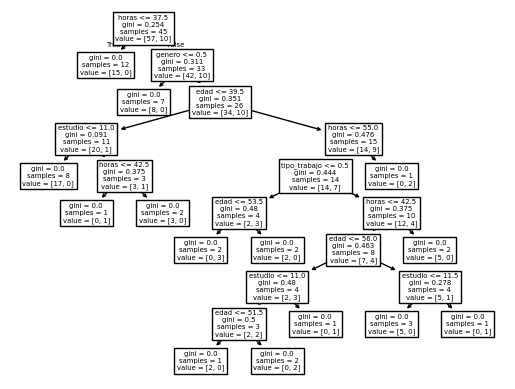

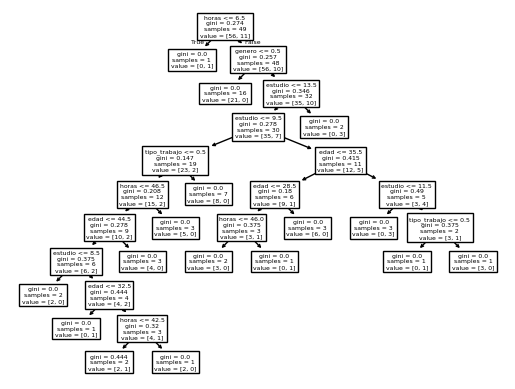

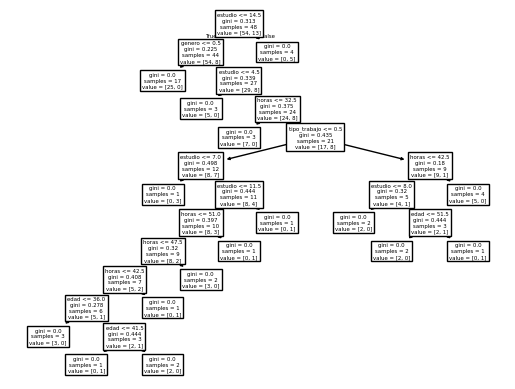

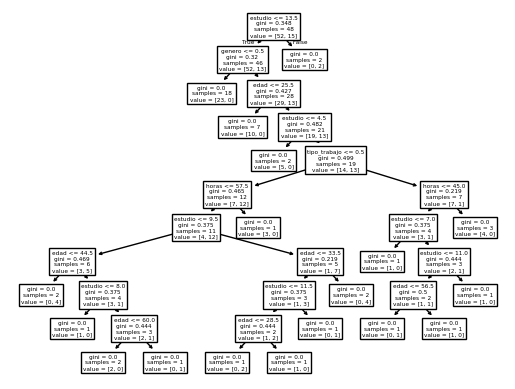

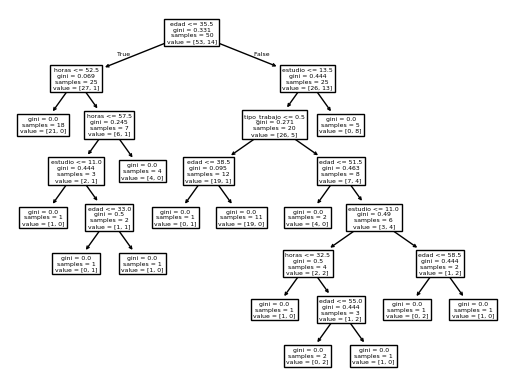

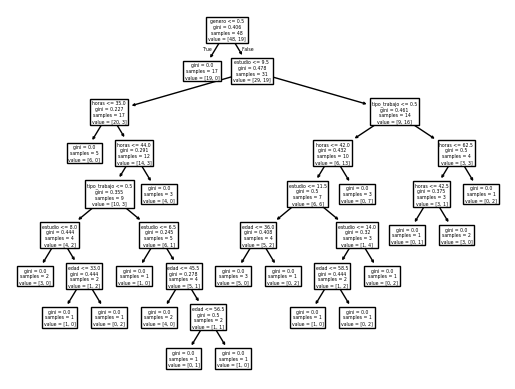

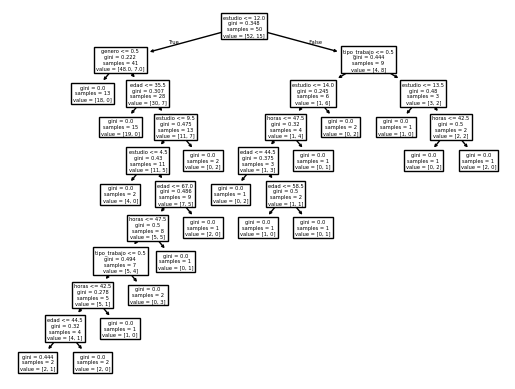

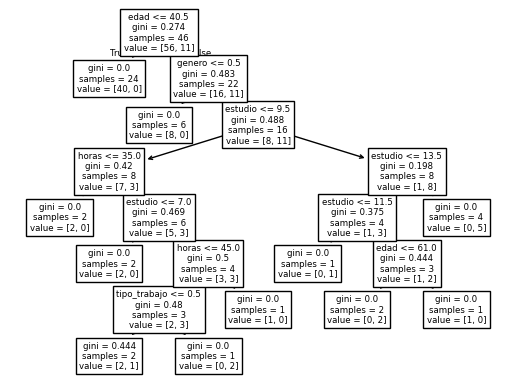

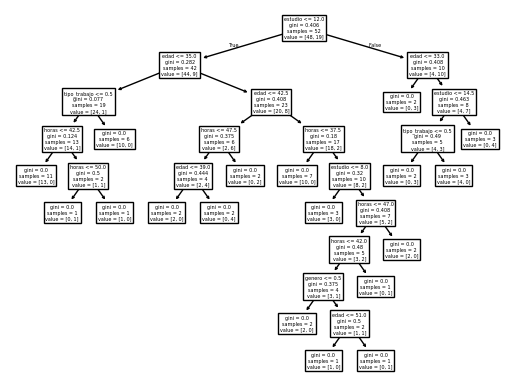

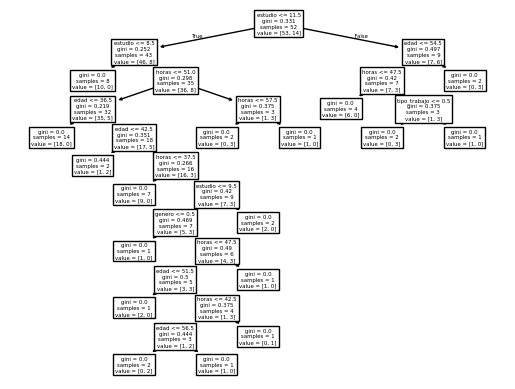

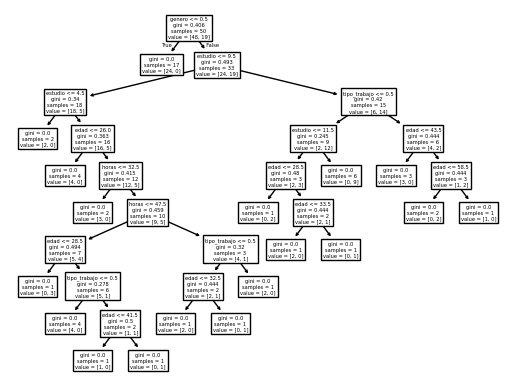

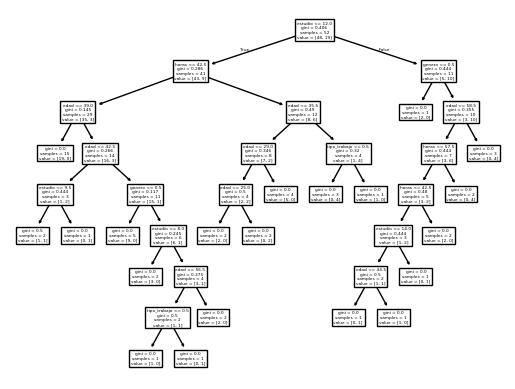

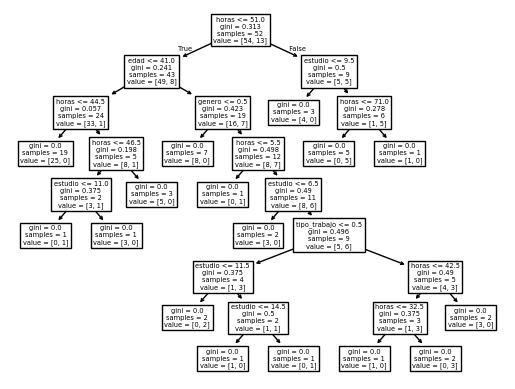

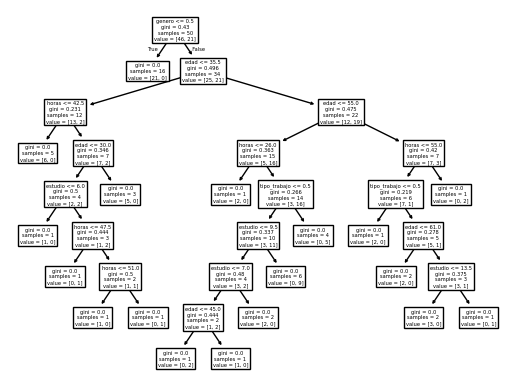

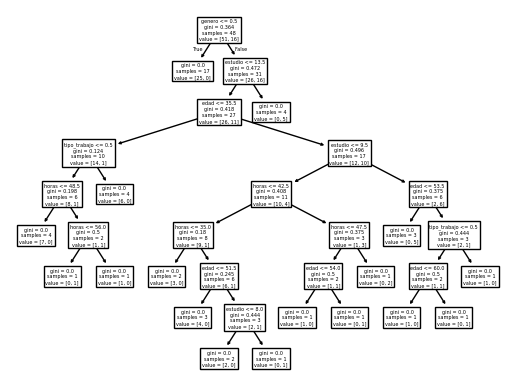

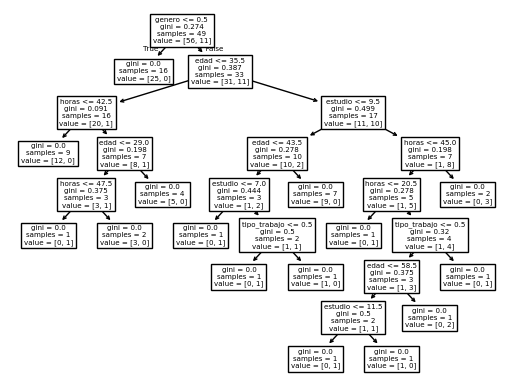

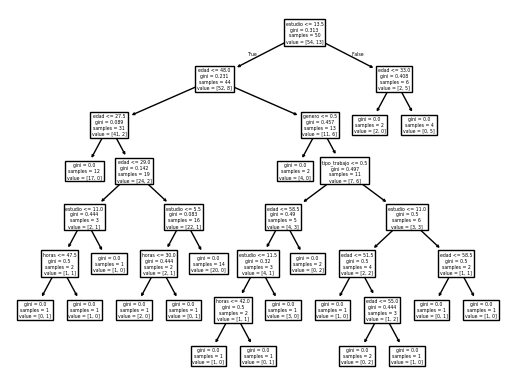

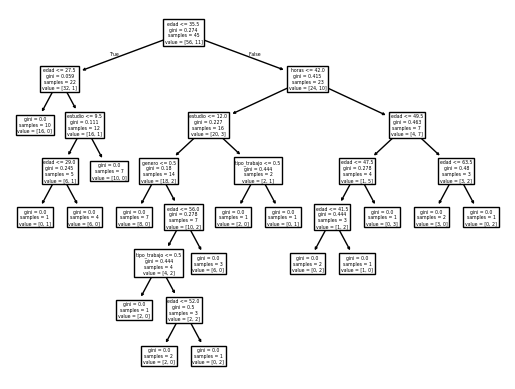

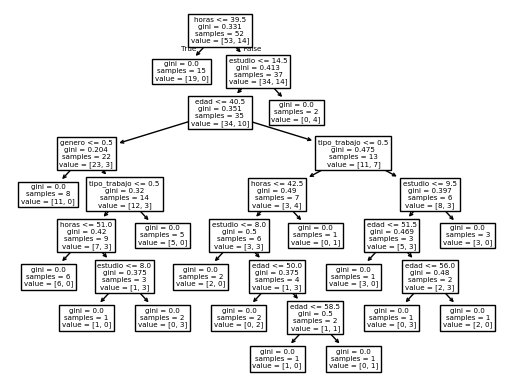

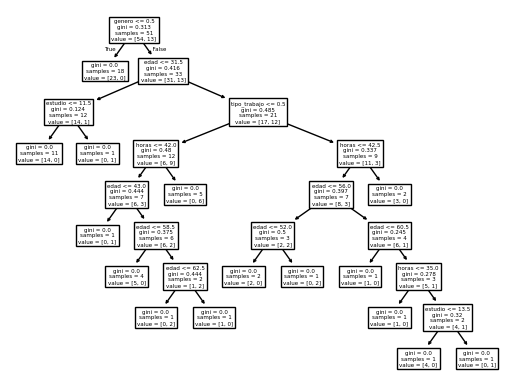

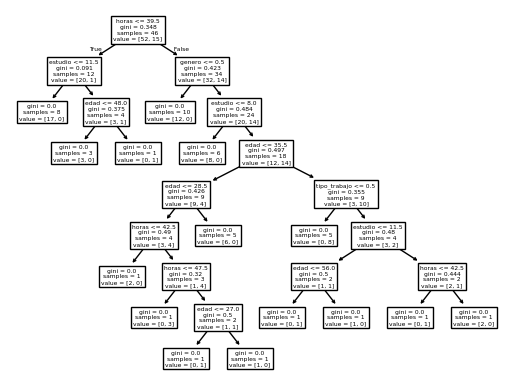

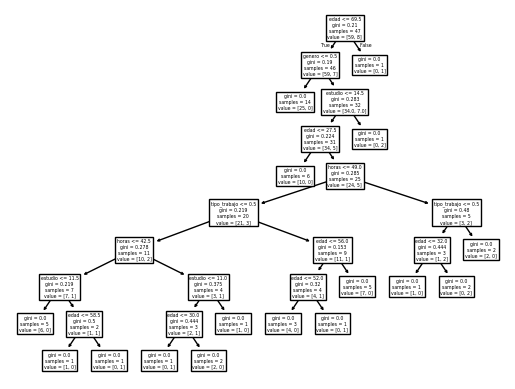

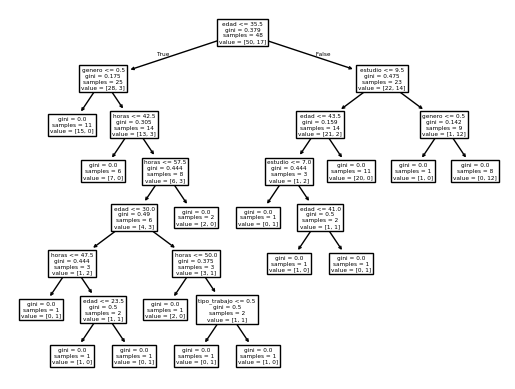

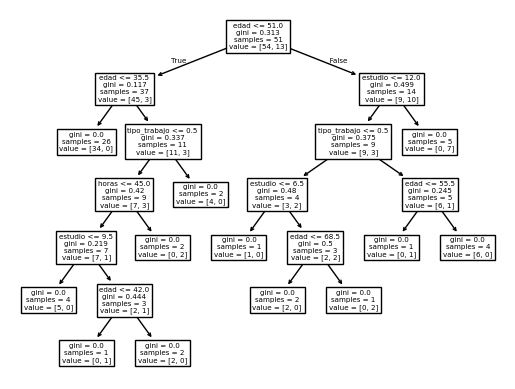

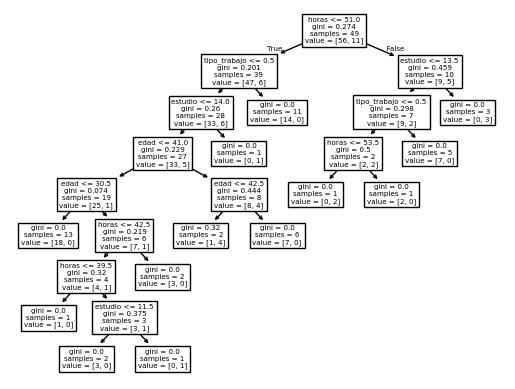

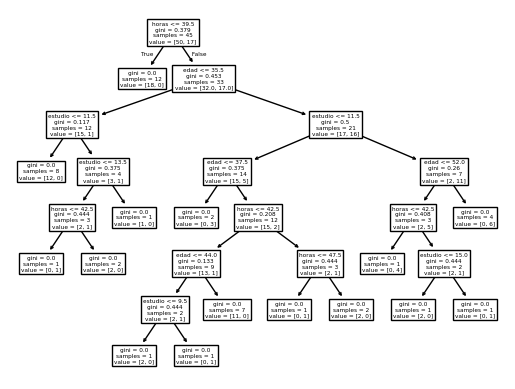

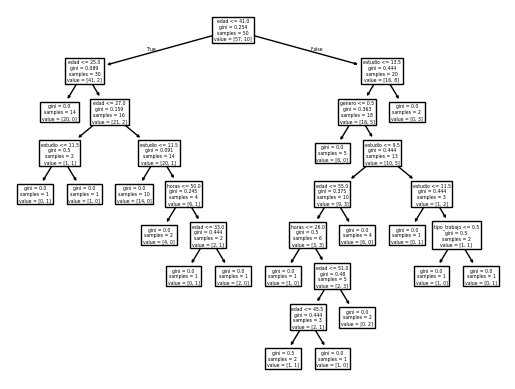

In [16]:
import matplotlib.pyplot as plt
from sklearn import tree

for arbol in bosque.estimators_:
  tree.plot_tree(arbol, feature_names=Personas.columns[:-1])
  plt.show()